In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

colors = ["white", "lightblue", "blue", "darkblue"]
cmap = mcolors.LinearSegmentedColormap.from_list("precip_cmap", colors)

norm = mcolors.Normalize(vmin=0, vmax=10)

def rmse(sample, target):
    return np.sqrt(np.mean((sample - target) ** 2))

In [4]:
def destandardize(
    sample,
    pr_stats_path='/mimer/NOBACKUP/groups/mlhighres/projects/detex/HCLIM_EC-Earth3-Veg/standardized_new/mean_std_remapped.pr_EUR-11_EC-Earth3-Veg_historical_r1i1p1f1_HCLIMcom-SMHI_HCLIM43-ALADIN_v1-r1_day_1951-2014_mm_day_noleap.npy', 
    tas_stats_path='/mimer/NOBACKUP/groups/mlhighres/projects/detex/HCLIM_EC-Earth3-Veg/standardized_new/mean_std_remapped.tas_EUR-11_EC-Earth3-Veg_historical_r1i1p1f1_HCLIMcom-SMHI_HCLIM43-ALADIN_v1-r1_day_1951-2014_noleap.npy'
):
    pr_mean, pr_std = np.load(pr_stats_path)
    tas_mean, tas_std = np.load(tas_stats_path)

    return sample * np.array([pr_std, tas_std]) + np.array([pr_mean, tas_mean])

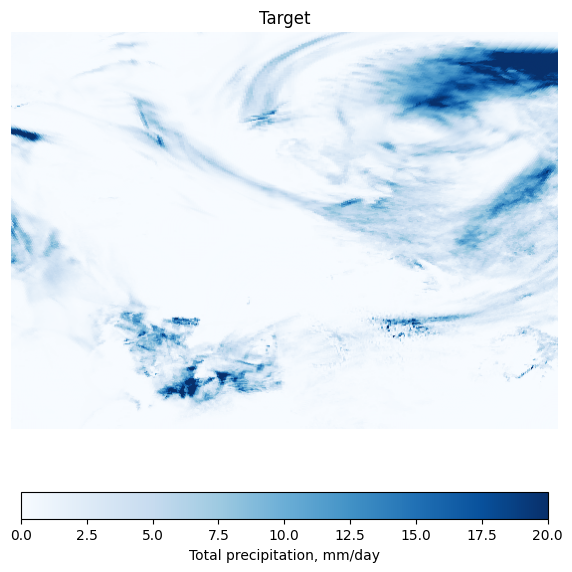

In [18]:
sample_id = 500
path = 'output/val_r1_4_members'

target = torch.load(f'{path}/example_target_{sample_id}.pt')
target = destandardize(target.numpy().reshape(400, 550, 2))

vmin = 0
vmax = 20

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(np.flipud(target[:, :, 0]), vmin=vmin, vmax=vmax, cmap='Blues')  # Use diverging colormap if needed
ax.set_title('Target')
ax.axis('off')

# Add colorbar for the image
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.12)
cbar.set_label('Total precipitation, mm/day')

plt.tight_layout()
plt.show()

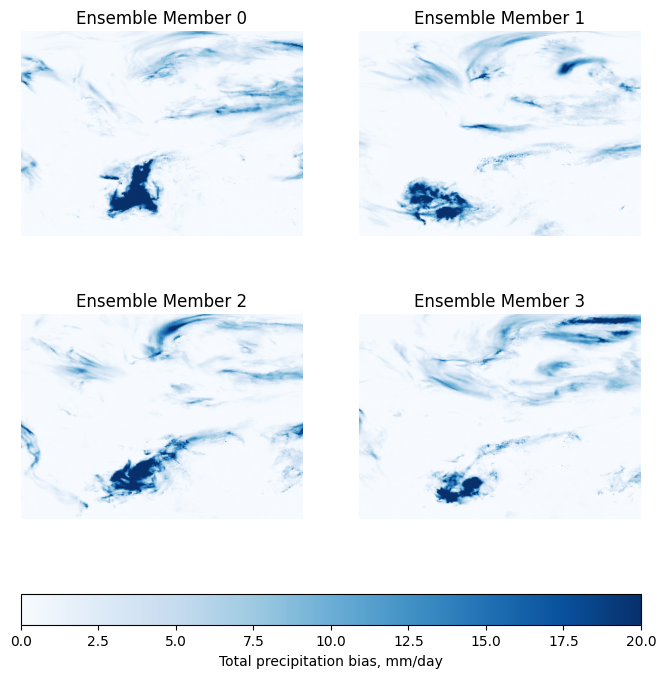

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

samples = []

# Load all samples
for i in range(4):
    sample = torch.load(f'{path}/example_ens_members_{sample_id}_{i}.pt')
    sample = destandardize(sample.numpy().reshape(400, 550, 2)) #- target
    samples.append(sample[:, :, 0])

# Determine global color limits
vmin = 0
vmax = 20

# Plot each sample
ims = []
for i in range(4):
    im = axes[i].imshow(np.flipud(samples[i]), vmin=vmin, vmax=vmax, cmap='Blues')
    axes[i].set_title(f'Ensemble Member {i}')
    axes[i].axis('off')
    ims.append(im)

# Adjust layout to make space for the colorbar
plt.subplots_adjust(bottom=0.1)  # leave space at the bottom

# Add colorbar below all subplots
cbar = fig.colorbar(ims[0], ax=axes, orientation='horizontal', fraction=0.05, pad=0.12)
cbar.set_label('Total precipitation bias, mm/day')

plt.show()

In [31]:
ensemble_members = 4
height = 400
width = 550
n_output_vars = 2
ensemble_mean_rmse = []
verbose = False
path = 'output/val_r1_4_members'
n_samples = 730

for sample_index in range(n_samples):
    if verbose:
        print(f"Sample {sample_index}...")
    sample = torch.load(f'{path}/example_ens_mean_{sample_index}.pt')
    sample = sample.cpu().detach().numpy().reshape(height, width, n_output_vars)
    mean_rmse = rmse(sample, target)
    if verbose:
        print(f"RMSE ensemble mean: {mean_rmse:.4f}")
    ensemble_mean_rmse.append(mean_rmse)
    for ensemble_index in range(ensemble_members):
        sample = torch.load(f'{path}/example_ens_members_{sample_index}_{ensemble_index}.pt')
        sample = sample.cpu().detach().numpy().reshape(height, width, n_output_vars)
        if verbose:
            print(f"RMSE member {ensemble_index}: {rmse(sample, target):.4f}")

ensemble_mean_rmse = np.array(ensemble_mean_rmse)